In [1]:
# Loads the Gaza and Ukraine casualty datasets for Math 50 Assignment 2
# into dataframes `gaza` and `ukraine`. Data is loaded directly from
# math50-data (raw GitHub URLs), so this notebook runs as-is in Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

In [2]:
GAZA_URL = "https://raw.githubusercontent.com/elevien/math50-data/main/data/gaza-casualties.csv"
UKRAINE_URL = "https://raw.githubusercontent.com/elevien/math50-data/main/data/ukraine-personnel-losses.csv"

BURN = 300  # drop the first 300 days: low, volatile early counts
GAZA_CEASEFIRE = pd.Timestamp("2025-10-10")


def load_gaza():
    # columns: time, counts (cumulative), daily (day-over-day increment),
    # period ("before"/"after" the ceasefire, in place of truncating),
    # plus a few of the other reported sub-counts
    df = pd.read_csv(GAZA_URL, parse_dates=["report_date"])
    counts = df["ext_killed_cum"].to_numpy().astype(float)
    daily = np.empty(len(counts))
    daily[0] = np.nan
    daily[1:] = counts[1:] - counts[:-1]

    period = np.empty(len(df), dtype=object)
    before = (df["report_date"] <= GAZA_CEASEFIRE).to_numpy()
    period[before] = "before"
    period[~before] = "after"

    out = pd.DataFrame({
        "time": df["report_date"],
        "counts": counts,
        "daily": daily,
        "period": period,
        "children_killed_cum": df["ext_killed_children_cum"].to_numpy(),
        "women_killed_cum": df["ext_killed_women_cum"].to_numpy(),
        "injured_cum": df["ext_injured_cum"].to_numpy(),
    })
    return out.iloc[BURN + 1:].reset_index(drop=True)


def load_ukraine():
    # columns: time, counts (cumulative), daily (day-over-day increment), POW
    df = pd.read_csv(UKRAINE_URL, parse_dates=["date"])
    counts = df["personnel"].to_numpy().astype(float)
    daily = np.empty(len(counts))
    daily[0] = np.nan
    daily[1:] = counts[1:] - counts[:-1]

    out = pd.DataFrame({
        "time": df["date"],
        "counts": counts,
        "daily": daily,
        "POW": df["POW"].to_numpy(),
    })
    return out.iloc[BURN + 1:].reset_index(drop=True)


gaza = load_gaza()
ukraine = load_ukraine()
gaza

,time,counts,daily,period,children_killed_cum,women_killed_cum,injured_cum
0,2024-08-03,39550.0,31.0,before,16314,10980,91280
1,2024-08-04,39583.0,33.0,before,16314,10980,91398
2,2024-08-05,39623.0,40.0,before,16314,10980,91469
3,2024-08-06,39653.0,30.0,before,16365,11012,91535
4,2024-08-07,39677.0,24.0,before,16365,11012,91645
...,...,...,...,...,...,...,...
776,2026-09-18,73821.0,0.0,after,20179,12500,174897
777,2026-09-19,73910.0,89.0,after,20179,12500,174914
778,2026-09-20,73910.0,0.0,after,20179,12500,174935
779,2026-09-21,73914.0,4.0,after,20179,12500,174952


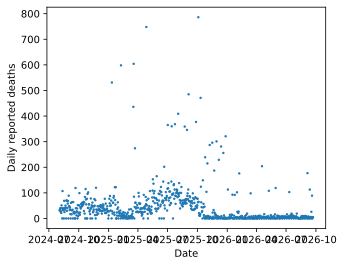

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(gaza.time, gaza.daily, ".", markersize=3)
ax.set_xlabel("Date")
ax.set_ylabel("Daily reported deaths")
plt.show()

In [4]:
ukraine

,time,counts,daily,POW
0,2022-12-23,100950.0,550.0,NaN
1,2022-12-24,101430.0,480.0,NaN
2,2022-12-25,102050.0,620.0,NaN
3,2022-12-26,102600.0,550.0,NaN
4,2022-12-27,103220.0,620.0,NaN
...,...,...,...,...
1365,2026-09-18,1514910.0,1420.0,NaN
1366,2026-09-19,1516430.0,1520.0,NaN
1367,2026-09-20,1517990.0,1560.0,NaN
1368,2026-09-21,1519650.0,1660.0,NaN
